In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_parquet("../../data/processed/olist-processed-dataset.parquet")
data = data[data["order_status"] == "delivered"]
data = data[data["order_purchase_timestamp"] >= "2017-01-01"]

##### Market Basket Analysis

In [3]:
product_group = data.groupby("order_id")["product_category_name"].nunique()
product_group.value_counts()

product_category_name
1    95433
2      760
3       18
Name: count, dtype: int64

&uarr; &uarr; &uarr;  
At this point, we tried a market basket / assosiation rule analysis. But since the dataset mostly includes orders with only one category (more then %99), we drop this type of analysis and went to a different categorical analysis.

##### Categorical Analysis

In [4]:
category_group = data.groupby("product_category_name").agg(
        revenue=("price", "sum"),
        average_product_price=("price", "mean"),
        sold_product=("order_item_id","count")
    ).sort_values(by="revenue", ascending=False)
category_group["revenue_pct"] = category_group["revenue"] * 100 / category_group["revenue"].sum()

sale volume/ revenue table  
&darr; &darr; &darr;

In [5]:
category_group

,revenue,average_product_price,sold_product,revenue_pct
product_category_name,,,,
health_beauty,1229557.50,130.498567,9422,9.328237
watches_gifts,1163465.91,198.713221,5855,8.826823
bed_bath_table,1022955.77,93.463296,10945,7.760820
sports_leisure,952840.40,113.244640,8414,7.228878
computers_accessories,888055.59,116.359485,7632,6.737378
...,...,...,...,...
flowers,1110.04,33.637576,33,0.008421
home_comfort_2,760.27,25.342333,30,0.005768
cds_dvds_musicals,730.00,52.142857,14,0.005538


In [6]:
data["review_score"].isna().sum()

np.int64(823)

In [7]:
df_clean_review = data.dropna(subset="review_score")
category_avg_review = df_clean_review.groupby("product_category_name").agg(
        avg_review_score=("review_score","mean")).sort_values(
        by="avg_review_score", ascending=False)

In [8]:
category_avg_review

,avg_review_score
product_category_name,
fashion_childrens_clothes,5.000000
cds_dvds_musicals,4.642857
books_general_interest,4.512195
books_imported,4.508772
costruction_tools_tools,4.444444
...,...
fixed_telephony,3.753036
home_comfort_2,3.629630
office_furniture,3.522135


In [9]:
first_35_ranked = category_group.head(35).join(category_avg_review)

In [10]:
first_35_ranked

,revenue,average_product_price,sold_product,revenue_pct,avg_review_score
product_category_name,,,,,
health_beauty,1229557.50,130.498567,9422,9.328237,4.192862
watches_gifts,1163465.91,198.713221,5855,8.826823,4.071244
bed_bath_table,1022955.77,93.463296,10945,7.760820,3.924328
sports_leisure,952840.40,113.244640,8414,7.228878,4.165052
computers_accessories,888055.59,116.359485,7632,6.737378,3.987362
furniture_decor,706237.17,87.243628,8095,5.357983,3.955589
housewares,614341.62,90.570783,6783,4.660802,4.108096
cool_stuff,609158.00,164.149286,3711,4.621476,4.195546
auto,577838.39,139.844722,4132,4.383865,4.116109


In [11]:
first_35_ranked[first_35_ranked["avg_review_score"] == first_35_ranked["avg_review_score"].max()]

,revenue,average_product_price,sold_product,revenue_pct,avg_review_score
product_category_name,,,,,
luggage_accessories,138701.63,128.785172,1077,1.052282,4.352283


&uarr; &uarr; &uarr;  
Product category with the highest review score

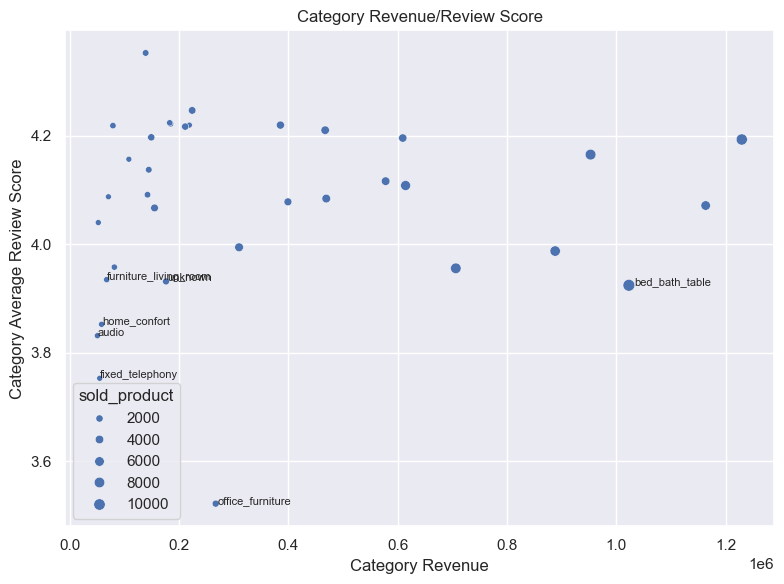

In [12]:
plt.figure(figsize=[8,6])
sns.scatterplot(data=first_35_ranked, x="revenue", y="avg_review_score", size="sold_product")
for idx,row in first_35_ranked.iterrows():
    if row["avg_review_score"] < 3.95:
        plt.text(
            x=row["revenue"] * 1.01,
            y=row["avg_review_score"],
            s=idx,
            fontsize=8)

plt.xlabel("Category Revenue")
plt.ylabel("Category Average Review Score")
plt.title("Category Revenue/Review Score")
plt.tight_layout()
plt.show()

##### Time Based Category Trend Analysis

In [13]:
data["year_month"] = data["order_purchase_timestamp"].dt.to_period("M")

In [14]:
category_time_revenue = data.groupby(["product_category_name","year_month"]).agg(monthly_revenue=("price", "sum"))
category_time_revenue_flat = category_time_revenue.reset_index()

In [15]:
category_peak_month = category_time_revenue_flat.loc[
    category_time_revenue_flat.groupby("product_category_name")["monthly_revenue"].idxmax()]

Peak months per category  
&darr; &darr; &darr;

In [16]:
category_peak_month

,product_category_name,year_month,monthly_revenue
9,agro_industry_and_commerce,2017-11,13932.49
31,air_conditioning,2018-01,4674.74
41,art,2017-05,6927.25
62,arts_and_craftmanship,2018-08,901.76
76,audio,2018-03,10606.69
...,...,...,...
1138,tablets_printing_image,2017-05,1514.98
1171,telephony,2018-08,36572.91
1182,toys,2017-11,62611.26
1204,unknown,2018-01,20993.63


In [17]:
month_peak_category = category_time_revenue_flat.loc[
    category_time_revenue_flat.groupby("year_month")["monthly_revenue"].idxmax()].sort_values(by="year_month")

Peak categories per month  
&darr; &darr; &darr;

In [18]:
month_peak_category

,product_category_name,year_month,monthly_revenue
649,furniture_decor,2017-01,13036.63
721,health_beauty,2017-02,22059.92
247,computers_accessories,2017-03,28078.80
125,bed_bath_table,2017-04,24092.89
724,health_beauty,2017-05,46340.06
336,cool_stuff,2017-06,38109.61
128,bed_bath_table,2017-07,62786.96
129,bed_bath_table,2017-08,56580.63
130,bed_bath_table,2017-09,52105.61
1221,watches_gifts,2017-10,64874.63


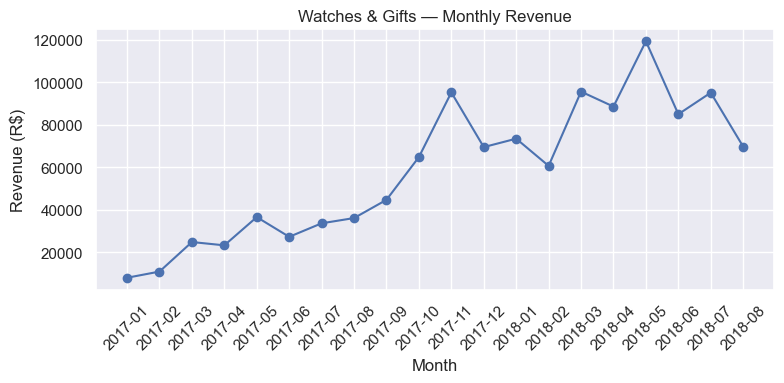

In [19]:
watches_trend = category_time_revenue_flat[
    category_time_revenue_flat["product_category_name"] == "watches_gifts"
].sort_values("year_month")

plt.figure(figsize=[8,4])
plt.plot(watches_trend["year_month"].astype(str), watches_trend["monthly_revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Watches & Gifts — Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.show()

&uarr; &uarr; &uarr;  
Even though the Black Friday's peak category is gifts; Watches & gifts category peaking at May 2018.